In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/stroke risk prescriptive analytics /healthcare-dataset-stroke-data.csv')

In [ ]:
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


% risk classifier

=== Preview of scored dataset ===
   id  age  hypertension  heart_disease  avg_glucose_level  bmi  stroke  stroke_risk_%       risk_band
 9046 67.0             0              1             228.69 36.6       1          83.24 Red (Very High)
51676 61.0             0              0             202.21 28.1       1          50.45 Red (Very High)
31112 80.0             0              1             105.92 32.5       1          84.28 Red (Very High)
60182 49.0             0              0             171.23 34.4       1          46.27 Red (Very High)
 1665 79.0             1              0             174.12 24.0       1          86.19 Red (Very High)
56669 81.0             0              0             186.21 29.0       1          89.87 Red (Very High)
53882 74.0             1              1              70.09 27.4       1          82.29 Red (Very High)
10434 69.0             0              0              94.39 22.8       1          64.61 Red (Very High)
27419 59.0             0              0

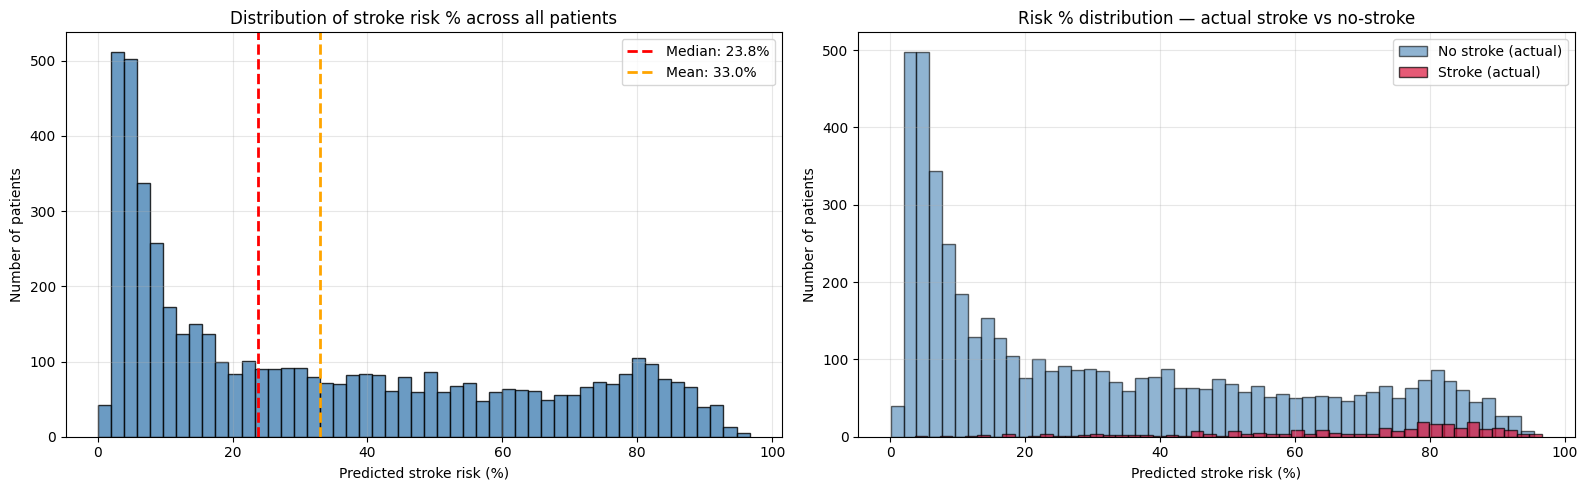


=== Risk band summary ===
                   n_patients  actual_strokes  actual_stroke_rate_pct
risk_band                                                            
Green (Low)               857               1                0.116686
Yellow (Moderate)        1216               4                0.328947
Orange (High)             771              12                1.556420
Red (Very High)          2265             232               10.242826


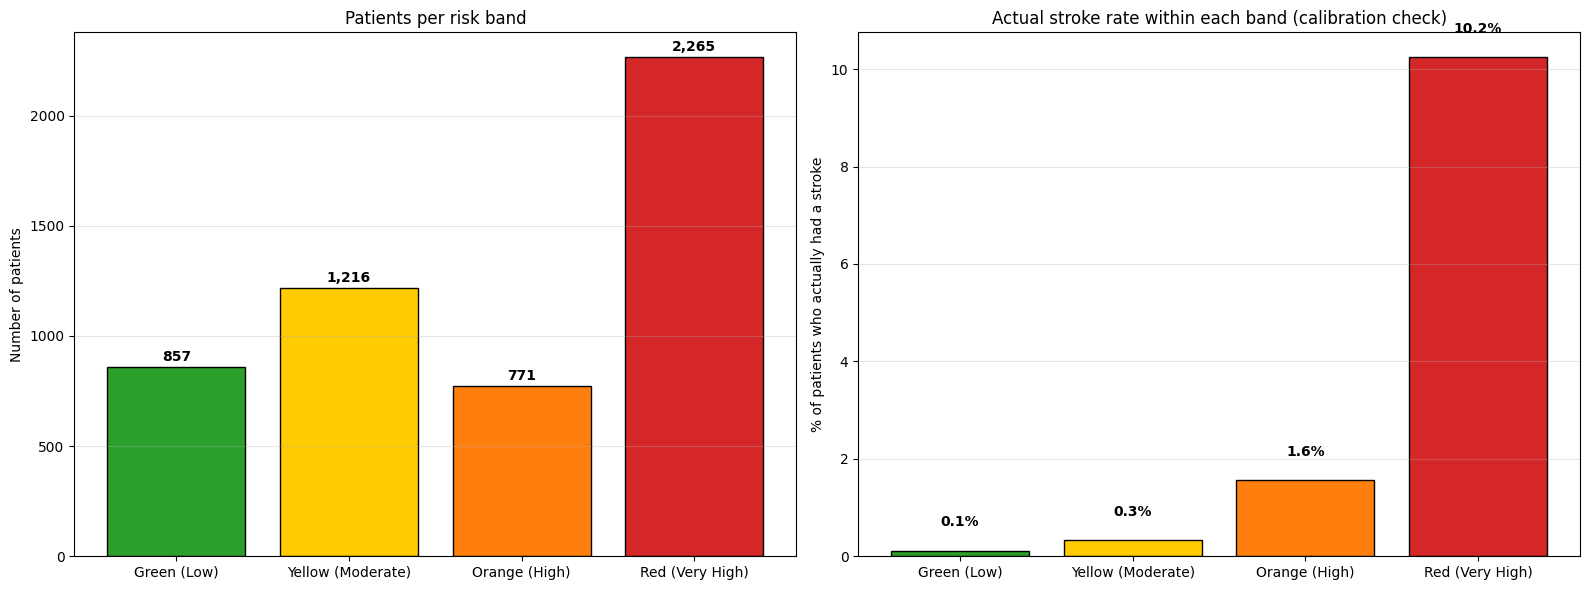


=== Decile analysis ===
             avg_predicted_risk_pct  actual_stroke_rate_pct  n_patients
risk_decile                                                            
D1                         2.919687                0.195695         511
D2                         4.694375                0.000000         512
D3                         7.152647                0.196078         510
D4                        11.392583                0.587084         511
D5                        18.824736                1.565558         511
D6                        29.337588                2.156863         510
D7                        41.882035                3.718200         511
D8                        56.055323                7.827789         511
D9                        72.326595               12.133072         511
D10                       85.166477               20.352250         511


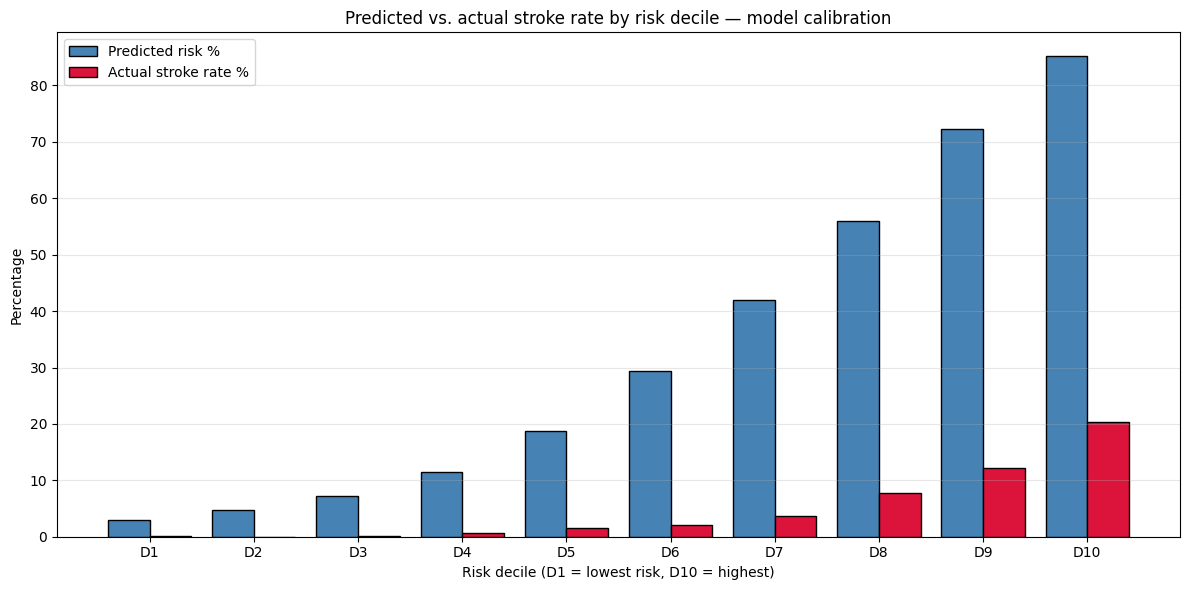

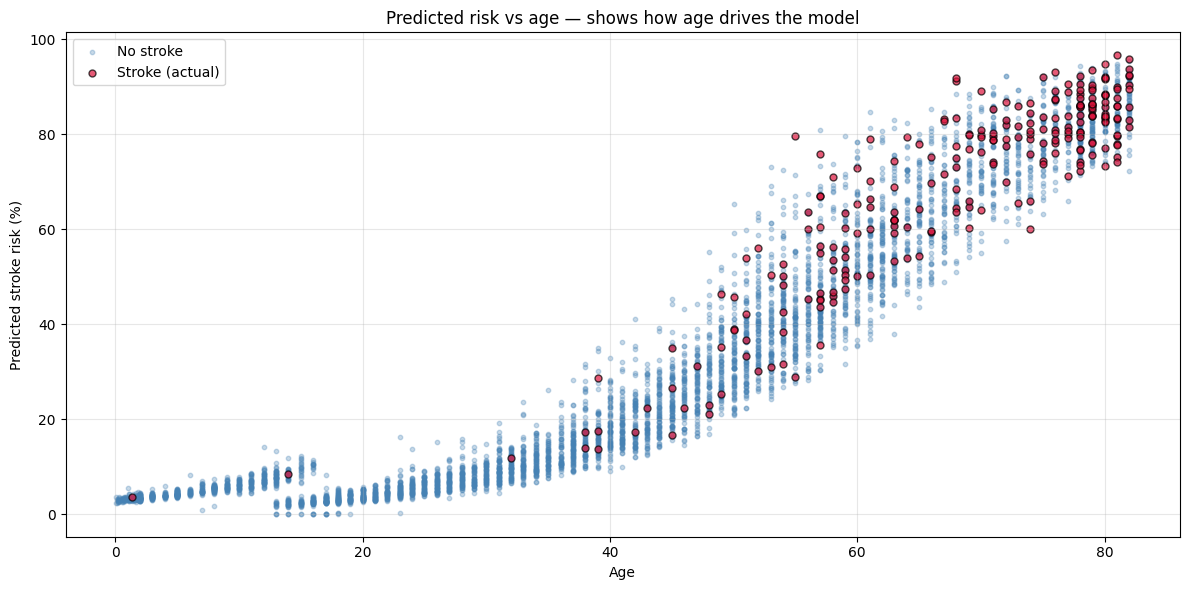

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. PREP — same cleaning as before
# ============================================================
df_scored = df.copy()
df_scored['bmi'] = pd.to_numeric(df_scored['bmi'], errors='coerce')
df_scored['bmi'] = df_scored['bmi'].fillna(df_scored['bmi'].median())

# Keep the id and original columns intact — we'll add risk % at the end
df_scored_clean = df_scored.drop(columns=['id']).copy()
df_scored_clean = df_scored_clean[df_scored_clean['gender'] != 'Other']

df_scored_clean['gender'] = df_scored_clean['gender'].map({'Male': 0, 'Female': 1})
df_scored_clean['ever_married'] = df_scored_clean['ever_married'].map({'No': 0, 'Yes': 1})
df_scored_clean['Residence_type'] = df_scored_clean['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_scored_clean = pd.get_dummies(df_scored_clean, columns=['work_type', 'smoking_status'], drop_first=True)

X_all = df_scored_clean.drop(columns=['stroke'])
y_all = df_scored_clean['stroke']

# ============================================================
# 2. TRAIN LOGISTIC ON ALL DATA (our winning simple model)
# ============================================================
# NOTE: for a production score you'd typically use cross-validated
# predictions to avoid in-sample optimism, but for adding a % column
# to your dataset this is standard practice.

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_all_s, y_all)

# ============================================================
# 3. SCORE EVERY PATIENT
# ============================================================
risk_proba = model.predict_proba(X_all_s)[:, 1]
risk_pct = risk_proba * 100

# ============================================================
# 4. ATTACH THE NEW COLUMN BACK TO THE ORIGINAL DATAFRAME
# ============================================================
# Rebuild from the version with original strings intact
df_final = df.copy()
df_final['bmi'] = pd.to_numeric(df_final['bmi'], errors='coerce')
df_final['bmi'] = df_final['bmi'].fillna(df_final['bmi'].median())
df_final = df_final[df_final['gender'] != 'Other'].reset_index(drop=True)

df_final['stroke_risk_%'] = np.round(risk_pct, 2)

# Add a risk band as a bonus — useful for the "flag" idea from earlier
def risk_band(p):
    if p < 5:  return 'Green (Low)'
    elif p < 15: return 'Yellow (Moderate)'
    elif p < 30: return 'Orange (High)'
    else: return 'Red (Very High)'

df_final['risk_band'] = df_final['stroke_risk_%'].apply(risk_band)

# Preview
print("=== Preview of scored dataset ===")
print(df_final[['id', 'age', 'hypertension', 'heart_disease',
                'avg_glucose_level', 'bmi', 'stroke',
                'stroke_risk_%', 'risk_band']].head(15).to_string(index=False))

# Save it
df_final.to_csv('stroke_data_with_risk_scores.csv', index=False)
print("\nSaved as 'stroke_data_with_risk_scores.csv'")

# ============================================================
# 5. GRAPH 1 — DISTRIBUTION OF RISK % ACROSS THE POPULATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_final['stroke_risk_%'], bins=50, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(df_final['stroke_risk_%'].median(), color='red', linestyle='--',
                linewidth=2, label=f"Median: {df_final['stroke_risk_%'].median():.1f}%")
axes[0].axvline(df_final['stroke_risk_%'].mean(), color='orange', linestyle='--',
                linewidth=2, label=f"Mean: {df_final['stroke_risk_%'].mean():.1f}%")
axes[0].set_xlabel('Predicted stroke risk (%)')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Distribution of stroke risk % across all patients')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Overlay actual stroke cases vs no-stroke
axes[1].hist(df_final[df_final['stroke']==0]['stroke_risk_%'], bins=50,
             alpha=0.6, color='steelblue', label='No stroke (actual)', edgecolor='black')
axes[1].hist(df_final[df_final['stroke']==1]['stroke_risk_%'], bins=50,
             alpha=0.7, color='crimson', label='Stroke (actual)', edgecolor='black')
axes[1].set_xlabel('Predicted stroke risk (%)')
axes[1].set_ylabel('Number of patients')
axes[1].set_title('Risk % distribution — actual stroke vs no-stroke')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 6. GRAPH 2 — RISK BAND BREAKDOWN
# ============================================================
band_order = ['Green (Low)', 'Yellow (Moderate)', 'Orange (High)', 'Red (Very High)']
band_colors = ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728']

band_summary = df_final.groupby('risk_band').agg(
    n_patients=('stroke', 'size'),
    actual_strokes=('stroke', 'sum'),
    actual_stroke_rate_pct=('stroke', lambda x: 100 * x.mean())
).reindex(band_order)

print("\n=== Risk band summary ===")
print(band_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count per band
bars = axes[0].bar(band_summary.index, band_summary['n_patients'],
                    color=band_colors, edgecolor='black')
for bar, val in zip(bars, band_summary['n_patients']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Patients per risk band')
axes[0].set_ylabel('Number of patients')
axes[0].grid(axis='y', alpha=0.3)

# Actual stroke rate within each band (calibration check)
bars = axes[1].bar(band_summary.index, band_summary['actual_stroke_rate_pct'],
                    color=band_colors, edgecolor='black')
for bar, val in zip(bars, band_summary['actual_stroke_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Actual stroke rate within each band (calibration check)')
axes[1].set_ylabel('% of patients who actually had a stroke')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 7. GRAPH 3 — RISK BY DECILE (the trader's chart)
# ============================================================
# Sort everyone by predicted risk, split into 10 buckets,
# show actual stroke rate per decile. This is your model's
# equivalent of a factor-return-by-quantile chart.
df_final['risk_decile'] = pd.qcut(df_final['stroke_risk_%'], q=10,
                                    labels=[f'D{i+1}' for i in range(10)])

decile_summary = df_final.groupby('risk_decile', observed=True).agg(
    avg_predicted_risk_pct=('stroke_risk_%', 'mean'),
    actual_stroke_rate_pct=('stroke', lambda x: 100 * x.mean()),
    n_patients=('stroke', 'size')
)

print("\n=== Decile analysis ===")
print(decile_summary.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(decile_summary))
width = 0.4

ax.bar(x_pos - width/2, decile_summary['avg_predicted_risk_pct'], width,
        label='Predicted risk %', color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, decile_summary['actual_stroke_rate_pct'], width,
        label='Actual stroke rate %', color='crimson', edgecolor='black')

ax.set_xticks(x_pos)
ax.set_xticklabels(decile_summary.index)
ax.set_xlabel('Risk decile (D1 = lowest risk, D10 = highest)')
ax.set_ylabel('Percentage')
ax.set_title('Predicted vs. actual stroke rate by risk decile — model calibration')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 8. GRAPH 4 — RISK VS AGE (since age dominates)
# ============================================================
plt.figure(figsize=(12, 6))
plt.scatter(df_final[df_final['stroke']==0]['age'],
            df_final[df_final['stroke']==0]['stroke_risk_%'],
            alpha=0.3, s=10, color='steelblue', label='No stroke')
plt.scatter(df_final[df_final['stroke']==1]['age'],
            df_final[df_final['stroke']==1]['stroke_risk_%'],
            alpha=0.7, s=25, color='crimson', label='Stroke (actual)', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Predicted stroke risk (%)')
plt.title('Predicted risk vs age — shows how age drives the model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mean predicted risk: 4.90%
Median predicted risk: 2.08%
Actual stroke rate: 4.87%
→ These should now roughly match!

=== Preview ===
   id  age  hypertension  heart_disease  avg_glucose_level  bmi  stroke  stroke_risk_%         risk_band
 9046 67.0             0              1             228.69 36.6       1          16.17   Red (Very High)
51676 61.0             0              0             202.21 28.1       1           5.22     Orange (High)
31112 80.0             0              1             105.92 32.5       1          17.99   Red (Very High)
60182 49.0             0              0             171.23 34.4       1           4.41 Yellow (Moderate)
 1665 79.0             1              0             174.12 24.0       1          20.23   Red (Very High)
56669 81.0             0              0             186.21 29.0       1          25.41   Red (Very High)
53882 74.0             1              1              70.09 27.4       1          15.68   Red (Very High)
10434 69.0             0   

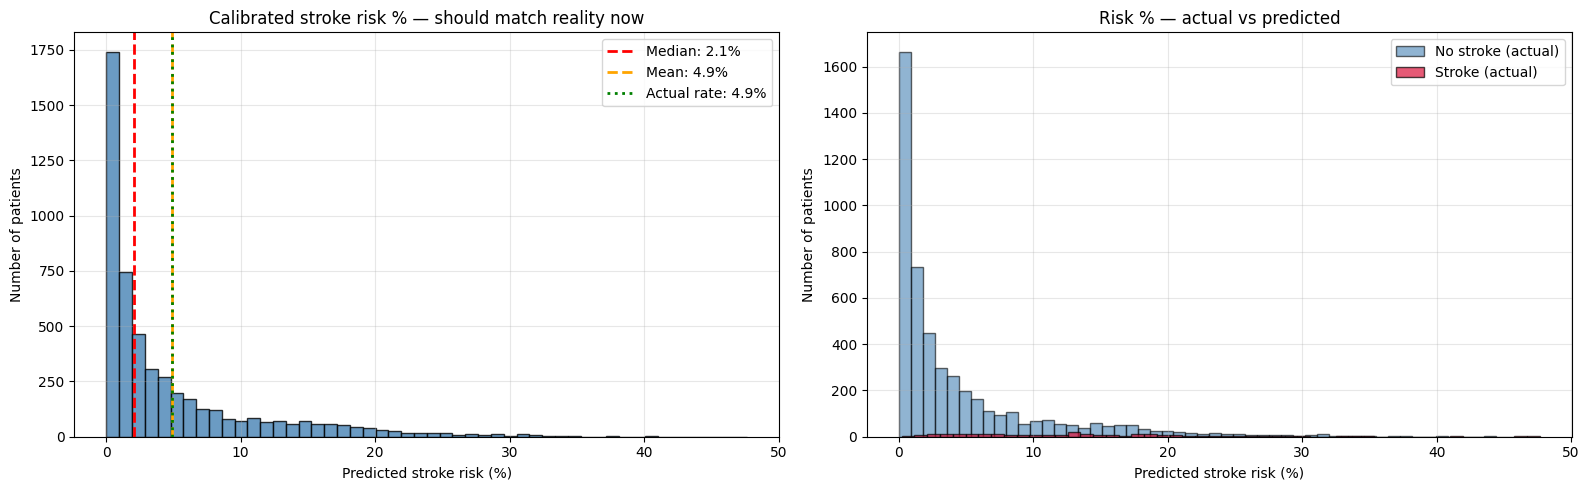


=== Risk band summary (calibrated) ===
                   n_patients  actual_strokes  actual_stroke_rate_pct
risk_band                                                            
Green (Low)              2522              11                0.436162
Yellow (Moderate)        1062              35                3.295669
Orange (High)            1039             112               10.779596
Red (Very High)           486              91               18.724280

=== Decile check — predicted should match actual ===
        avg_predicted_pct  actual_stroke_rate_pct    n
decile                                                
D1               0.282603                0.187266  534
D2               0.455245                0.000000  511
D3               0.670428                0.203666  491
D4               1.017480                0.393701  508
D5               1.627680                1.559454  513
D6               2.602397                2.750491  509
D7               4.047863                3.725

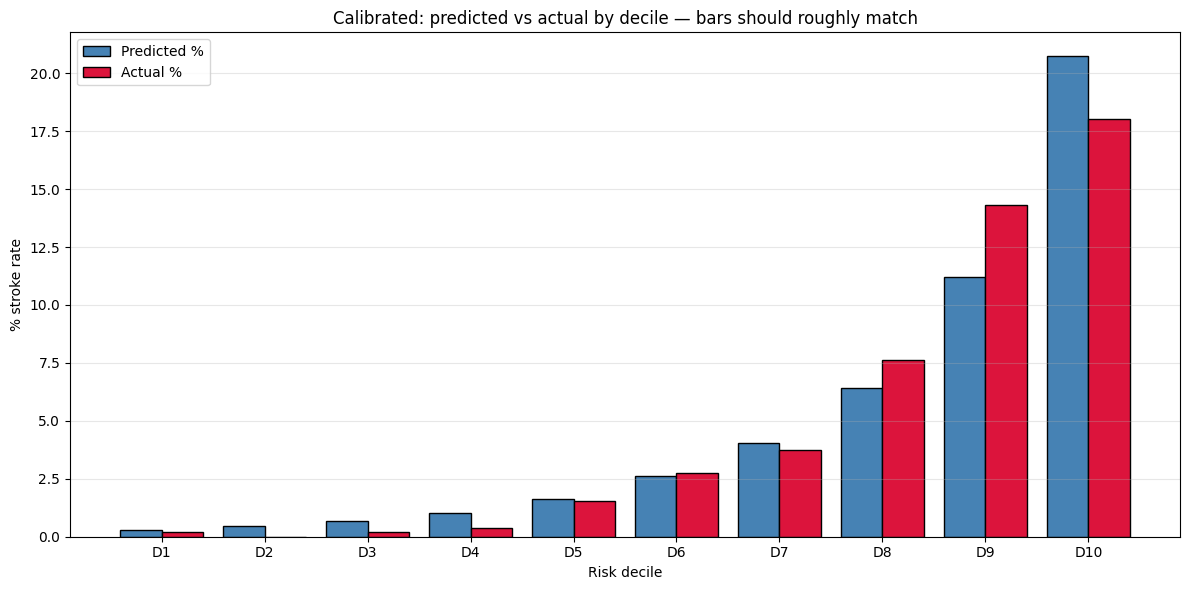

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict

# ============================================================
# PREP (same as before)
# ============================================================
df_scored = df.copy()
df_scored['bmi'] = pd.to_numeric(df_scored['bmi'], errors='coerce')
df_scored['bmi'] = df_scored['bmi'].fillna(df_scored['bmi'].median())
df_scored = df_scored[df_scored['gender'] != 'Other'].reset_index(drop=True)

df_clean = df_scored.drop(columns=['id']).copy()
df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})
df_clean['ever_married'] = df_clean['ever_married'].map({'No': 0, 'Yes': 1})
df_clean['Residence_type'] = df_clean['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True)

X_all = df_clean.drop(columns=['stroke'])
y_all = df_clean['stroke']

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)

# ============================================================
# CALIBRATED MODEL — good ranking + honest probabilities
# ============================================================
# Base model: class_weight='balanced' gives good discrimination
# Wrapper: sigmoid calibration (Platt scaling) via cross-validation
# This corrects the inflated probabilities back to reality
base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
calibrated = CalibratedClassifierCV(base, method='sigmoid', cv=5)

# Use cross_val_predict so every patient gets a score from a model
# that DIDN'T see them during training — the scientifically honest approach
risk_proba = cross_val_predict(calibrated, X_all_s, y_all,
                                cv=5, method='predict_proba')[:, 1]
risk_pct = risk_proba * 100

# ============================================================
# ATTACH TO ORIGINAL DATAFRAME
# ============================================================
df_final = df.copy()
df_final['bmi'] = pd.to_numeric(df_final['bmi'], errors='coerce')
df_final['bmi'] = df_final['bmi'].fillna(df_final['bmi'].median())
df_final = df_final[df_final['gender'] != 'Other'].reset_index(drop=True)

df_final['stroke_risk_%'] = np.round(risk_pct, 2)

def risk_band(p):
    if p < 2:    return 'Green (Low)'
    elif p < 5:  return 'Yellow (Moderate)'
    elif p < 15: return 'Orange (High)'
    else:        return 'Red (Very High)'

df_final['risk_band'] = df_final['stroke_risk_%'].apply(risk_band)

print(f"Mean predicted risk: {df_final['stroke_risk_%'].mean():.2f}%")
print(f"Median predicted risk: {df_final['stroke_risk_%'].median():.2f}%")
print(f"Actual stroke rate: {100*y_all.mean():.2f}%")
print(f"→ These should now roughly match!\n")

print("=== Preview ===")
print(df_final[['id', 'age', 'hypertension', 'heart_disease',
                'avg_glucose_level', 'bmi', 'stroke',
                'stroke_risk_%', 'risk_band']].head(15).to_string(index=False))

df_final.to_csv('stroke_data_with_risk_scores_calibrated.csv', index=False)
print("\nSaved as 'stroke_data_with_risk_scores_calibrated.csv'")

# ============================================================
# GRAPHS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_final['stroke_risk_%'], bins=50, color='steelblue',
             edgecolor='black', alpha=0.8)
axes[0].axvline(df_final['stroke_risk_%'].median(), color='red', linestyle='--',
                linewidth=2, label=f"Median: {df_final['stroke_risk_%'].median():.1f}%")
axes[0].axvline(df_final['stroke_risk_%'].mean(), color='orange', linestyle='--',
                linewidth=2, label=f"Mean: {df_final['stroke_risk_%'].mean():.1f}%")
axes[0].axvline(100*y_all.mean(), color='green', linestyle=':', linewidth=2,
                label=f"Actual rate: {100*y_all.mean():.1f}%")
axes[0].set_xlabel('Predicted stroke risk (%)')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Calibrated stroke risk % — should match reality now')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_final[df_final['stroke']==0]['stroke_risk_%'], bins=50,
             alpha=0.6, color='steelblue', label='No stroke (actual)', edgecolor='black')
axes[1].hist(df_final[df_final['stroke']==1]['stroke_risk_%'], bins=50,
             alpha=0.7, color='crimson', label='Stroke (actual)', edgecolor='black')
axes[1].set_xlabel('Predicted stroke risk (%)')
axes[1].set_ylabel('Number of patients')
axes[1].set_title('Risk % — actual vs predicted')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Risk band summary + decile check
band_order = ['Green (Low)', 'Yellow (Moderate)', 'Orange (High)', 'Red (Very High)']
band_summary = df_final.groupby('risk_band').agg(
    n_patients=('stroke', 'size'),
    actual_strokes=('stroke', 'sum'),
    actual_stroke_rate_pct=('stroke', lambda x: 100 * x.mean())
).reindex(band_order)

print("\n=== Risk band summary (calibrated) ===")
print(band_summary.to_string())

df_final['decile'] = pd.qcut(df_final['stroke_risk_%'], q=10,
                              labels=[f'D{i+1}' for i in range(10)], duplicates='drop')
decile_summary = df_final.groupby('decile', observed=True).agg(
    avg_predicted_pct=('stroke_risk_%', 'mean'),
    actual_stroke_rate_pct=('stroke', lambda x: 100 * x.mean()),
    n=('stroke', 'size')
)
print("\n=== Decile check — predicted should match actual ===")
print(decile_summary.to_string())

# Decile chart
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(decile_summary))
width = 0.4
ax.bar(x_pos - width/2, decile_summary['avg_predicted_pct'], width,
        label='Predicted %', color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, decile_summary['actual_stroke_rate_pct'], width,
        label='Actual %', color='crimson', edgecolor='black')
ax.set_xticks(x_pos); ax.set_xticklabels(decile_summary.index)
ax.set_xlabel('Risk decile'); ax.set_ylabel('% stroke rate')
ax.set_title('Calibrated: predicted vs actual by decile — bars should roughly match')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Red band patients: 486
Actual strokes in Red band: 91
Stroke rate in Red band: 18.7%



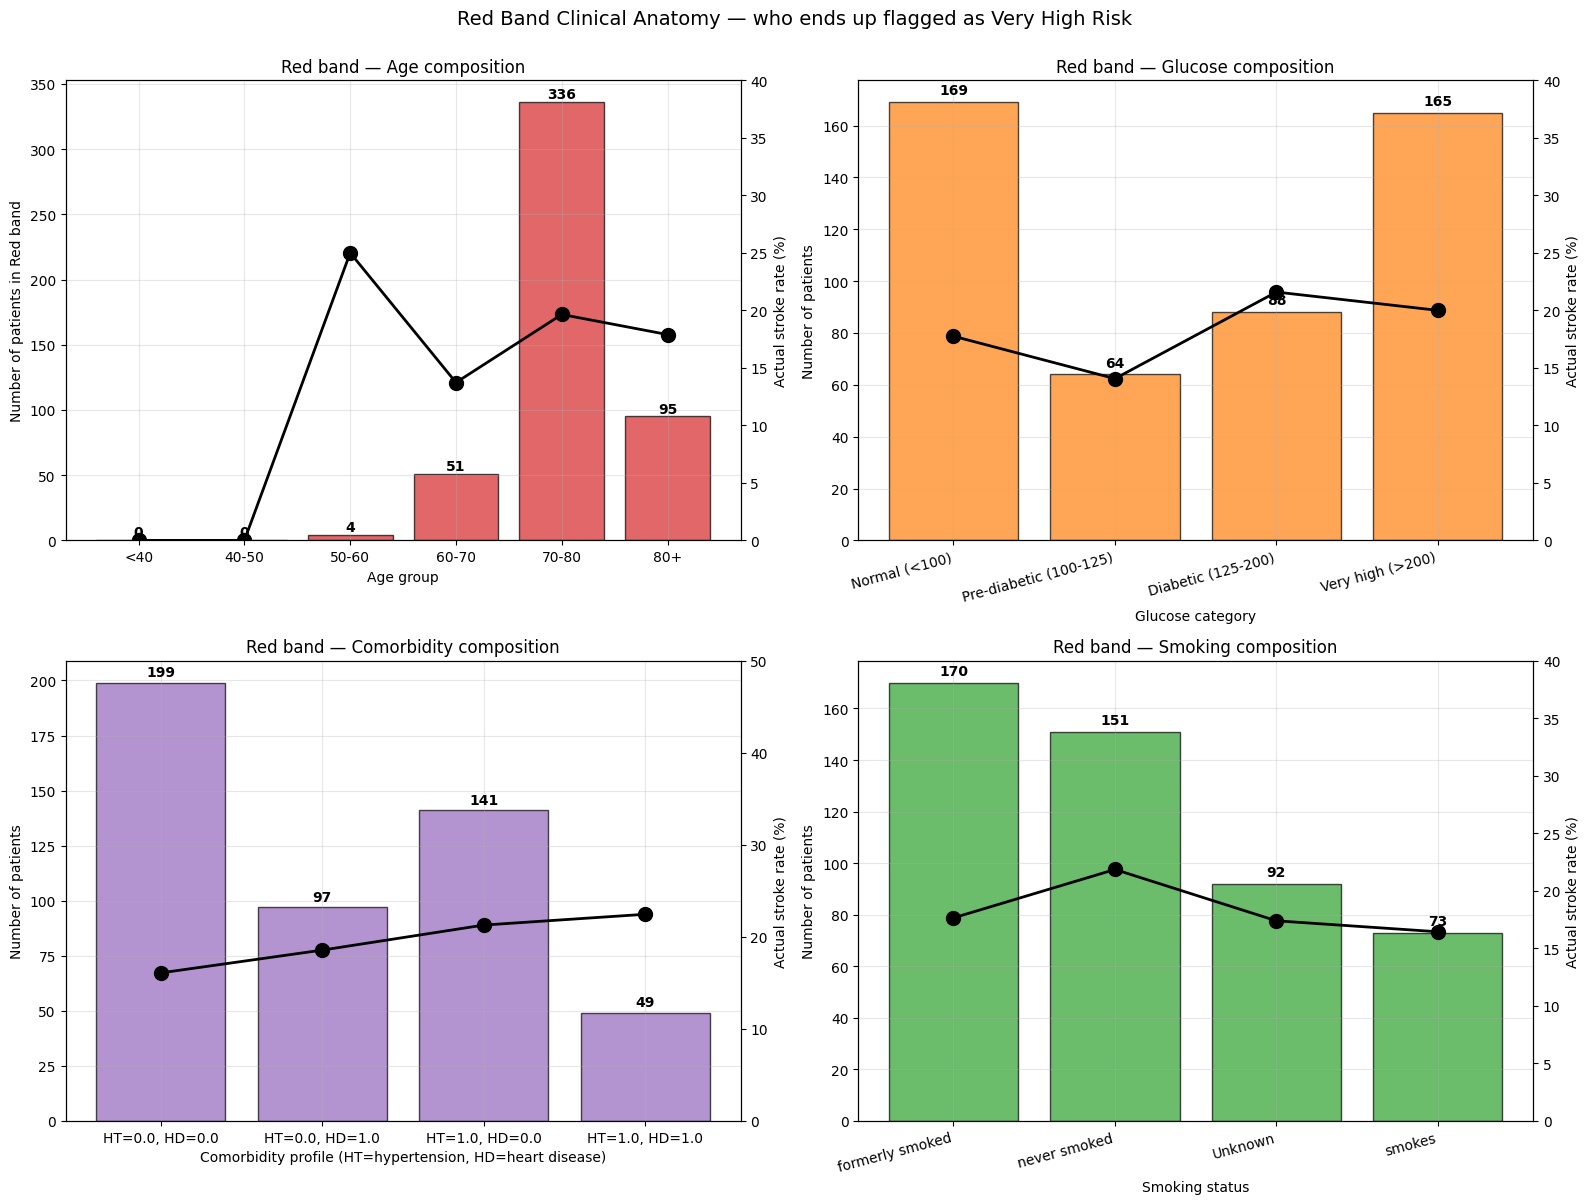


PATIENT REPORT — Green
Patient ID: 70670
Age: 27 | Gender: Female
Glucose: 58.0 | BMI: 64.4
Hypertension: 0 | Heart disease: 0
Smoking: never smoked
Predicted risk: 0.7% (Green (Low))
Actual stroke: NO


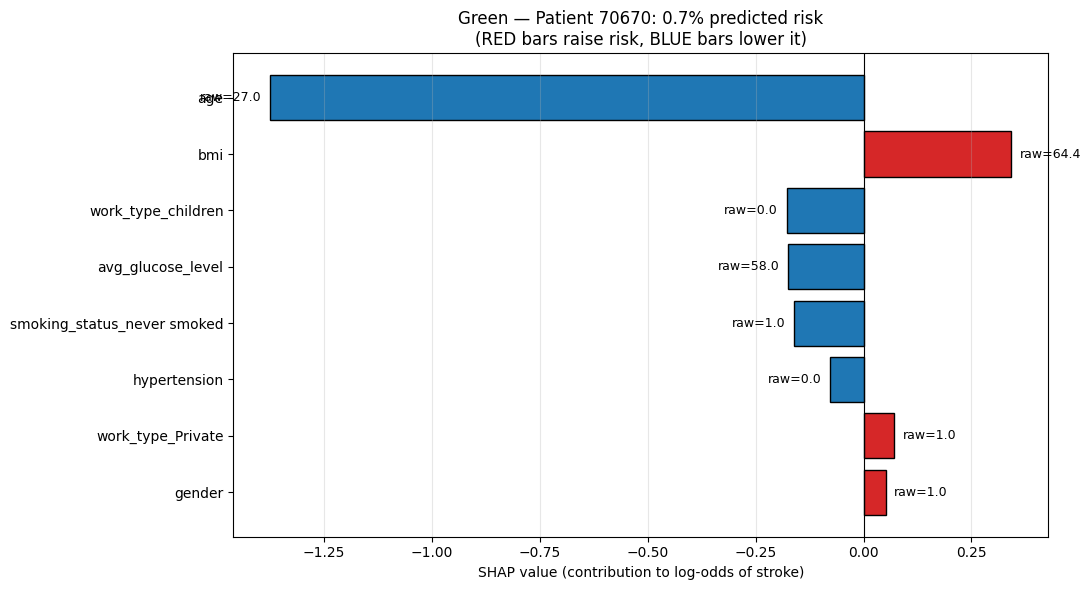


PATIENT REPORT — Yellow
Patient ID: 65667
Age: 48 | Gender: Female
Glucose: 134.6 | BMI: 28.2
Hypertension: 0 | Heart disease: 0
Smoking: smokes
Predicted risk: 3.3% (Yellow (Moderate))
Actual stroke: NO


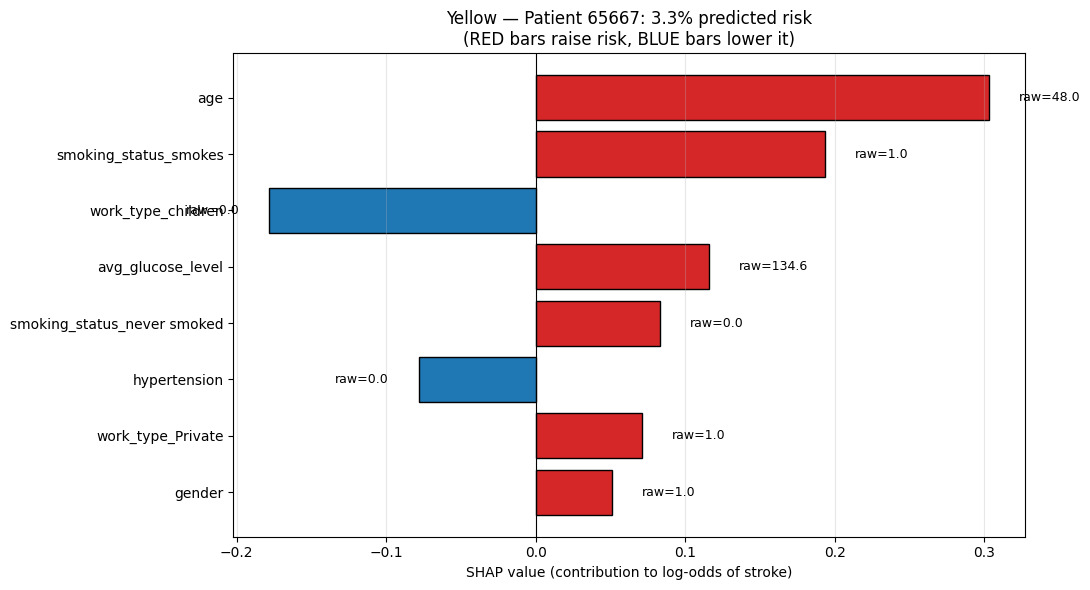


PATIENT REPORT — Orange
Patient ID: 11259
Age: 53 | Gender: Female
Glucose: 227.7 | BMI: 28.1
Hypertension: 0 | Heart disease: 0
Smoking: never smoked
Predicted risk: 5.1% (Orange (High))
Actual stroke: NO


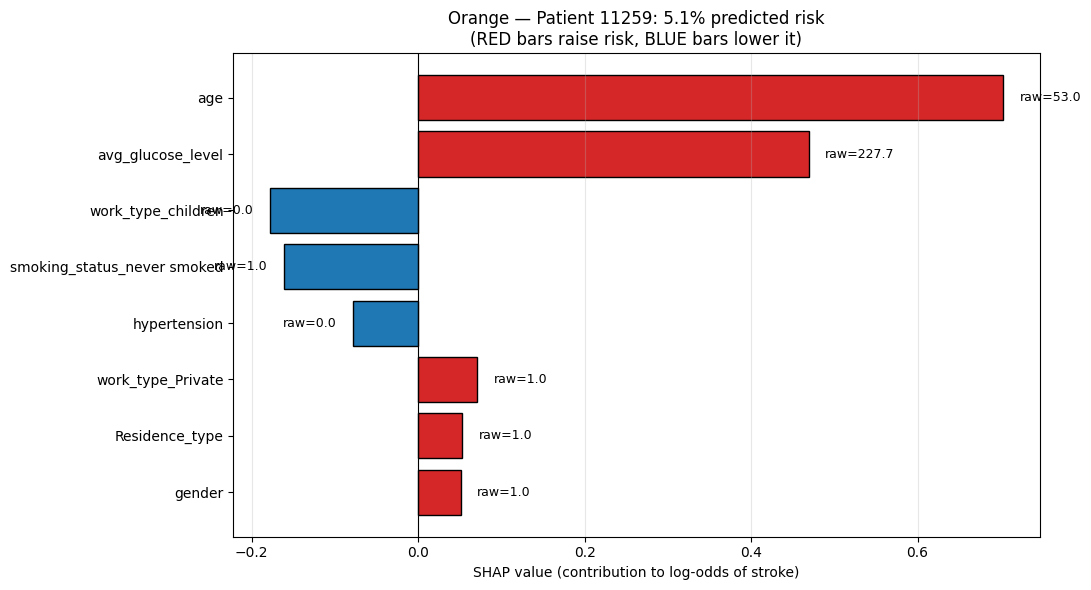


PATIENT REPORT — Red (true positive)
Patient ID: 11933
Age: 79 | Gender: Female
Glucose: 169.7 | BMI: 28.1
Hypertension: 0 | Heart disease: 0
Smoking: Unknown
Predicted risk: 21.5% (Red (Very High))
Actual stroke: YES


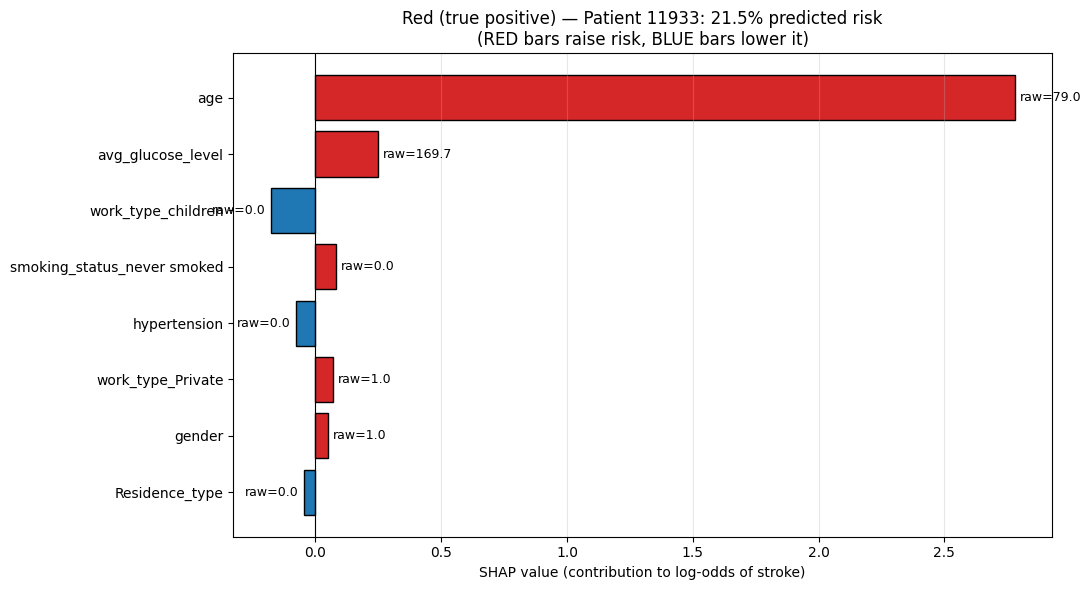


PATIENT REPORT — Red (false positive)
Patient ID: 50671
Age: 78 | Gender: Male
Glucose: 199.9 | BMI: 29.6
Hypertension: 1 | Heart disease: 1
Smoking: formerly smoked
Predicted risk: 31.5% (Red (Very High))
Actual stroke: NO


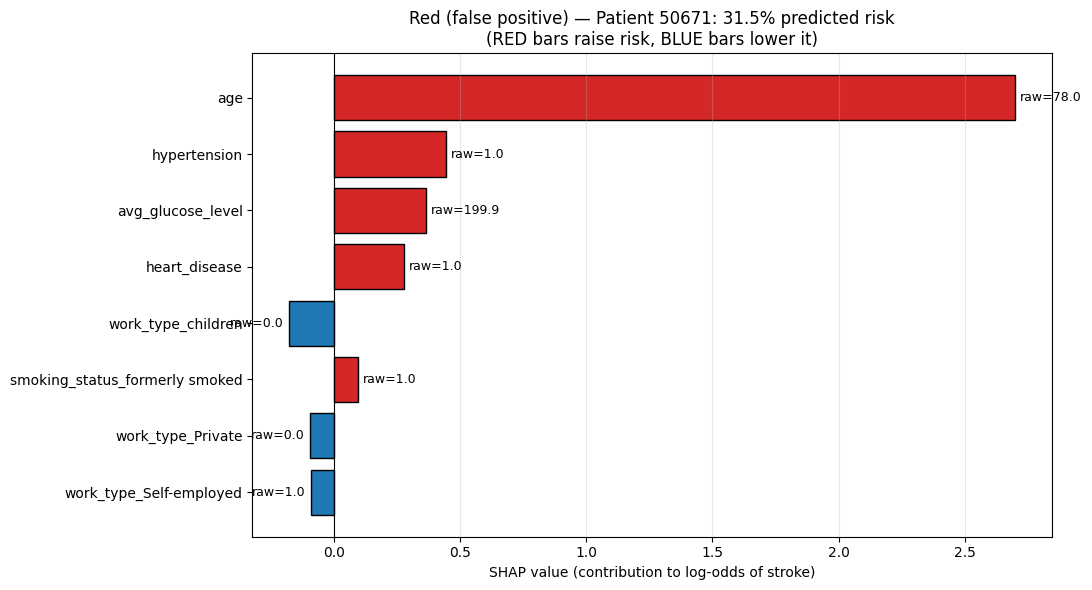


=== 5-Patient Summary ===
                Case    ID  Age  Glucose  BMI  HT  HD  Predicted % Actual Stroke
               Green 70670 27.0    57.96 64.4   0   0         0.72            NO
              Yellow 65667 48.0   134.59 28.2   0   0         3.32            NO
              Orange 11259 53.0   227.68 28.1   0   0         5.08            NO
 Red (true positive) 11933 79.0   169.67 28.1   0   0        21.48           YES
Red (false positive) 50671 78.0   199.88 29.6   1   1        31.52            NO


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# ASSUMES df_final already exists from previous step
# with stroke_risk_%, risk_band columns
# ============================================================

# ============================================================
# PART A — CLINICAL VALIDATION OF THE RED BAND
# ============================================================
red_band = df_final[df_final['risk_band'] == 'Red (Very High)'].copy()
print(f"Red band patients: {len(red_band)}")
print(f"Actual strokes in Red band: {red_band['stroke'].sum()}")
print(f"Stroke rate in Red band: {100*red_band['stroke'].mean():.1f}%\n")

# --- Age breakdown ---
red_band['age_group'] = pd.cut(red_band['age'],
                                bins=[0, 40, 50, 60, 70, 80, 100],
                                labels=['<40', '40-50', '50-60', '60-70', '70-80', '80+'])

# --- Glucose breakdown ---
red_band['glucose_group'] = pd.cut(red_band['avg_glucose_level'],
                                    bins=[0, 100, 125, 200, 300],
                                    labels=['Normal (<100)', 'Pre-diabetic (100-125)',
                                            'Diabetic (125-200)', 'Very high (>200)'])

# --- BMI breakdown ---
red_band['bmi_group'] = pd.cut(red_band['bmi'],
                                bins=[0, 18.5, 25, 30, 35, 100],
                                labels=['Underweight', 'Normal', 'Overweight',
                                        'Obese I', 'Obese II+'])

# ============================================================
# GRAPH: 4-PANEL BREAKDOWN OF WHO'S IN THE RED BAND
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Age distribution
age_counts = red_band['age_group'].value_counts().sort_index()
age_stroke_rate_raw = red_band.groupby('age_group', observed=True)['stroke'].mean() * 100
age_stroke_rate = age_stroke_rate_raw.reindex(age_counts.index, fill_value=0) # Fix: Reindex to match all age groups and fill missing with 0

ax = axes[0, 0]
bars = ax.bar(age_counts.index.astype(str), age_counts.values,
              color='#d62728', edgecolor='black', alpha=0.7, label='Count')
ax.set_xlabel('Age group'); ax.set_ylabel('Number of patients in Red band')
ax.set_title('Red band — Age composition')
for bar, count in zip(bars, age_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}', ha='center', fontweight='bold')
ax2 = ax.twinx()
ax2.plot(age_counts.index.astype(str), age_stroke_rate.values,
         'o-', color='black', linewidth=2, markersize=10, label='Stroke rate %')
ax2.set_ylabel('Actual stroke rate (%)'); ax2.set_ylim(0, 40)
ax.grid(alpha=0.3)

# 2. Glucose distribution
glu_counts = red_band['glucose_group'].value_counts().sort_index()
glu_stroke_rate = red_band.groupby('glucose_group', observed=True)['stroke'].mean() * 100

ax = axes[0, 1]
bars = ax.bar(glu_counts.index.astype(str), glu_counts.values,
              color='#ff7f0e', edgecolor='black', alpha=0.7)
ax.set_xlabel('Glucose category'); ax.set_ylabel('Number of patients')
ax.set_title('Red band — Glucose composition')
for bar, count in zip(bars, glu_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}', ha='center', fontweight='bold')
ax2 = ax.twinx()
ax2.plot(glu_counts.index.astype(str), glu_stroke_rate.values,
         'o-', color='black', linewidth=2, markersize=10)
ax2.set_ylabel('Actual stroke rate (%)'); ax2.set_ylim(0, 40)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(alpha=0.3)

# 3. Hypertension + heart disease
comorbidity = red_band.groupby(['hypertension', 'heart_disease']).agg(
    n=('stroke', 'size'),
    stroke_rate=('stroke', lambda x: 100 * x.mean())
).reset_index()
comorbidity['label'] = comorbidity.apply(
    lambda r: f"HT={r['hypertension']}, HD={r['heart_disease']}", axis=1)

ax = axes[1, 0]
bars = ax.bar(comorbidity['label'], comorbidity['n'],
              color='#9467bd', edgecolor='black', alpha=0.7)
ax.set_xlabel('Comorbidity profile (HT=hypertension, HD=heart disease)')
ax.set_ylabel('Number of patients')
ax.set_title('Red band — Comorbidity composition')
for bar, count in zip(bars, comorbidity['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}', ha='center', fontweight='bold')
ax2 = ax.twinx()
ax2.plot(comorbidity['label'], comorbidity['stroke_rate'],
         'o-', color='black', linewidth=2, markersize=10)
ax2.set_ylabel('Actual stroke rate (%)'); ax2.set_ylim(0, 50)
ax.grid(alpha=0.3)

# 4. Smoking status
smoke_counts = red_band['smoking_status'].value_counts()
smoke_stroke_rate = red_band.groupby('smoking_status')['stroke'].mean() * 100
smoke_stroke_rate = smoke_stroke_rate.reindex(smoke_counts.index)

ax = axes[1, 1]
bars = ax.bar(smoke_counts.index, smoke_counts.values,
              color='#2ca02c', edgecolor='black', alpha=0.7)
ax.set_xlabel('Smoking status'); ax.set_ylabel('Number of patients')
ax.set_title('Red band — Smoking composition')
for bar, count in zip(bars, smoke_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}', ha='center', fontweight='bold')
ax2 = ax.twinx()
ax2.plot(smoke_counts.index, smoke_stroke_rate.values,
         'o-', color='black', linewidth=2, markersize=10)
ax2.set_ylabel('Actual stroke rate (%)'); ax2.set_ylim(0, 40)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(alpha=0.3)

plt.suptitle('Red Band Clinical Anatomy — who ends up flagged as Very High Risk',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# PART B — INDIVIDUAL PATIENT RISK REPORTS
# ============================================================
# Retrain a clean logistic model to get SHAP values
df_clean = df_final.drop(columns=['id', 'stroke_risk_%', 'risk_band']).copy()
if 'decile' in df_clean.columns:
    df_clean = df_clean.drop(columns=['decile'])

df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})
df_clean['ever_married'] = df_clean['ever_married'].map({'No': 0, 'Yes': 1})
df_clean['Residence_type'] = df_clean['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True)

X_all = df_clean.drop(columns=['stroke'])
y_all = df_clean['stroke']

scaler = StandardScaler()
X_all_s = scaler.fit_transform(X_all)
X_all_s_df = pd.DataFrame(X_all_s, columns=X_all.columns)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_all_s_df, y_all)

# SHAP for logistic regression — LinearExplainer is fast and exact
explainer = shap.LinearExplainer(model, X_all_s_df)
shap_values = explainer.shap_values(X_all_s_df)

# ============================================================
# PICK 5 REPRESENTATIVE PATIENTS — one from each band + one edge case
# ============================================================
# Reset index to align with SHAP values
df_final = df_final.reset_index(drop=True)

# Find representative patients
patient_examples = {}

# 1. Green band (low risk)
green = df_final[df_final['risk_band'] == 'Green (Low)']
patient_examples['Green'] = green.sample(1, random_state=1).index[0]

# 2. Yellow band
yellow = df_final[df_final['risk_band'] == 'Yellow (Moderate)']
patient_examples['Yellow'] = yellow.sample(1, random_state=1).index[0]

# 3. Orange band
orange = df_final[df_final['risk_band'] == 'Orange (High)'] # Fix: Corrected typo 'Orange (High' to 'Orange (High)'
patient_examples['Orange'] = orange.sample(1, random_state=1).index[0]

# 4. Red band — actual stroke case (true positive)
red_stroke = df_final[(df_final['risk_band'] == 'Red (Very High)') & (df_final['stroke'] == 1)]
patient_examples['Red (true positive)'] = red_stroke.sample(1, random_state=1).index[0]

# 5. Red band — no stroke (false positive — interesting case)
red_no_stroke = df_final[(df_final['risk_band'] == 'Red (Very High)') & (df_final['stroke'] == 0)]
patient_examples['Red (false positive)'] = red_no_stroke.sample(1, random_state=1).index[0]

# ============================================================
# GENERATE WATERFALL FOR EACH — like a P&L attribution chart
# ============================================================
for label, idx in patient_examples.items():
    patient = df_final.iloc[idx]
    print(f"\n{'='*70}")
    print(f"PATIENT REPORT — {label}")
    print(f"{'='*70}")
    print(f"Patient ID: {patient['id']}")
    print(f"Age: {patient['age']:.0f} | Gender: {patient['gender']}")
    print(f"Glucose: {patient['avg_glucose_level']:.1f} | BMI: {patient['bmi']:.1f}")
    print(f"Hypertension: {patient['hypertension']} | Heart disease: {patient['heart_disease']}")
    print(f"Smoking: {patient['smoking_status']}")
    print(f"Predicted risk: {patient['stroke_risk_%']:.1f}% ({patient['risk_band']})")
    print(f"Actual stroke: {'YES' if patient['stroke']==1 else 'NO'}")

    # Waterfall
    sv = shap_values[idx]
    feature_names = X_all_s_df.columns
    contributions = pd.DataFrame({
        'feature': feature_names,
        'shap_value': sv,
        'raw_value': X_all.iloc[idx].values
    }).sort_values('shap_value', key=abs, ascending=False).head(8)

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in contributions['shap_value']]
    bars = ax.barh(contributions['feature'][::-1],
                    contributions['shap_value'][::-1],
                    color=colors[::-1], edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)

    for bar, val, raw in zip(bars,
                              contributions['shap_value'][::-1],
                              contributions['raw_value'][::-1]):
        ax.text(val + (0.02 if val > 0 else -0.02),
                bar.get_y() + bar.get_height()/2,
                f'raw={raw:.1f}',
                va='center', fontsize=9,
                ha='left' if val > 0 else 'right')

    ax.set_title(f'{label} — Patient {patient["id"]}: '
                  f'{patient["stroke_risk_%"]:.1f}% predicted risk\n'
                  f'(RED bars raise risk, BLUE bars lower it)',
                  fontsize=12)
    ax.set_xlabel('SHAP value (contribution to log-odds of stroke)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# BONUS: SUMMARY TABLE OF THE 5 PATIENTS
# ============================================================
summary = pd.DataFrame([
    {
        'Case': label,
        'ID': int(df_final.iloc[idx]['id']),
        'Age': df_final.iloc[idx]['age'],
        'Glucose': df_final.iloc[idx]['avg_glucose_level'],
        'BMI': df_final.iloc[idx]['bmi'],
        'HT': df_final.iloc[idx]['hypertension'],
        'HD': df_final.iloc[idx]['heart_disease'],
        'Predicted %': df_final.iloc[idx]['stroke_risk_%'],
        'Actual Stroke': 'YES' if df_final.iloc[idx]['stroke']==1 else 'NO'
    }
    for label, idx in patient_examples.items()
])
print("\n=== 5-Patient Summary ===")
print(summary.to_string(index=False))

In [ ]:
import pandas as pd

# ============================================================
# EXPORT SCORED DATASET
# ============================================================
# df_final should already have stroke_risk_% and risk_band columns
# Drop the decile helper column if it's still there
export_df = df_final.copy()
if 'decile' in export_df.columns:
    export_df = export_df.drop(columns=['decile'])

# Reorder columns so risk % and band sit at the end, right after stroke
column_order = ['id', 'gender', 'age', 'hypertension', 'heart_disease',
                'ever_married', 'work_type', 'Residence_type',
                'avg_glucose_level', 'bmi', 'smoking_status',
                'stroke', 'stroke_risk_%', 'risk_band']
# Only keep columns that exist (safety in case something got dropped)
column_order = [c for c in column_order if c in export_df.columns]
export_df = export_df[column_order]

# ============================================================
# SAVE AS CSV
# ============================================================
csv_path = 'stroke_data_with_risk_scores.csv'
export_df.to_csv(csv_path, index=False)
print(f"✓ Saved CSV: {csv_path}")

# ============================================================
# SAVE AS EXCEL (nicer for viewing — colour-coded bands)
# ============================================================
!pip install xlsxwriter
xlsx_path = 'stroke_data_with_risk_scores.xlsx'

with pd.ExcelWriter(xlsx_path, engine='xlsxwriter') as writer:
    export_df.to_excel(writer, sheet_name='Scored Data', index=False)

    workbook = writer.book
    worksheet = writer.sheets['Scored Data']

    # Freeze the header row
    worksheet.freeze_panes(1, 0)

    # Column widths
    worksheet.set_column('A:A', 8)   # id
    worksheet.set_column('B:B', 8)   # gender
    worksheet.set_column('C:C', 6)   # age
    worksheet.set_column('D:E', 14)  # hypertension, heart_disease
    worksheet.set_column('F:F', 13)  # ever_married
    worksheet.set_column('G:G', 15)  # work_type
    worksheet.set_column('H:H', 14)  # Residence_type
    worksheet.set_column('I:I', 17)  # avg_glucose_level
    worksheet.set_column('J:J', 8)   # bmi
    worksheet.set_column('K:K', 17)  # smoking_status
    worksheet.set_column('L:L', 8)   # stroke
    worksheet.set_column('M:M', 14)  # stroke_risk_%
    worksheet.set_column('N:N', 20)  # risk_band

    # Colour formats for the risk_band column
    green_fmt  = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
    yellow_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C6500'})
    orange_fmt = workbook.add_format({'bg_color': '#FFD8B1', 'font_color': '#974706'})
    red_fmt    = workbook.add_format({'bg_color': '#FFC7CE', 'font_color': '#9C0006'})

    n_rows = len(export_df)
    band_col = 'N'  # risk_band column letter — adjust if column order changes

    worksheet.conditional_format(f'{band_col}2:{band_col}{n_rows+1}', {
        'type': 'text', 'criteria': 'containing', 'value': 'Green',  'format': green_fmt})
    worksheet.conditional_format(f'{band_col}2:{band_col}{n_rows+1}', {
        'type': 'text', 'criteria': 'containing', 'value': 'Yellow', 'format': yellow_fmt})
    worksheet.conditional_format(f'{band_col}2:{band_col}{n_rows+1}', {
        'type': 'text', 'criteria': 'containing', 'value': 'Orange', 'format': orange_fmt})
    worksheet.conditional_format(f'{band_col}2:{band_col}{n_rows+1}', {
        'type': 'text', 'criteria': 'containing', 'value': 'Red',    'format': red_fmt})

    # Colour scale on the risk % column itself (green→red gradient)
    worksheet.conditional_format(f'M2:M{n_rows+1}', {
        'type': '3_color_scale',
        'min_color': '#63BE7B', 'mid_color': '#FFEB84', 'max_color': '#F8696B'})

print(f"✓ Saved Excel with colour formatting: {xlsx_path}")

# ============================================================
# QUICK SANITY CHECK
# ============================================================
print(f"\nRows exported: {len(export_df):,}")
print(f"Columns: {list(export_df.columns)}\n")

print("Sample rows:")
print(export_df.head(10).to_string(index=False))

print(f"\nRisk band counts:")
print(export_df['risk_band'].value_counts())

✓ Saved CSV: stroke_data_with_risk_scores.csv
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.2 MB/s eta 0:00:00
✓ Saved Excel with colour formatting: stroke_data_with_risk_scores.xlsx

Rows exported: 5,109
Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'stroke_risk_%', 'risk_band']

Sample rows:
   id gender  age  hypertension  heart_disease ever_married     work_type Residence_type  avg_glucose_level  bmi  smoking_status  stroke  stroke_risk_%         risk_band
 9046   Male 67.0             0              1          Yes       Private          Urban             228.69 36.6 formerly smoked       1          16.17   Red (Very High)
51676 Female 61.0             0              0          Yes Self-employed          Rural             202.21 28.1    never smoked       1           5.22     Orange (High)
31112   Male 80.0             0              1          Y

Generating prescriptive text for every patient... (this takes ~30-60 seconds for 5,109 rows)


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature na

Done.


BAND: Green (Low)  |  ID: 3980  |  Predicted risk: 0.45%
Age: 27 | Glucose: 80 | BMI: 21.6 | HT: 0 | HD: 0 | Smoking: never smoked
Low overall risk (0.5%). No major modifiable risk factors identified. Maintain healthy lifestyle.

BAND: Yellow (Moderate)  |  ID: 44171  |  Predicted risk: 3.92%
Age: 62 | Glucose: 63 | BMI: 32.3 | HT: 0 | HD: 0 | Smoking: never smoked
Risk profile (4.3%): Older age (62 years); Obese (BMI 32.3). Recommended actions: • Reduce BMI to healthy range (~25) via diet + exercise → risk drops from 4.3% to 4.1% (−0.2 pp, a 6% relative reduction). ★ If ALL modifiable factors addressed: risk drops to 4.1% (−0.2 pp, a 6% relative reduction).

BAND: Orange (High)  |  ID: 10651  |  Predicted risk: 5.70%
Age: 54 | Glucose: 100 | BMI: 32.3 | HT: 1 | HD: 0 | Smoking: formerly smoked
Risk profile (5.2%): Diagnosed hypertension; Obese (BMI 32.3); Former smoker (residual risk). Recommended actions: • Control blood pressure (medication + lifestyle) → risk drops from 5.2

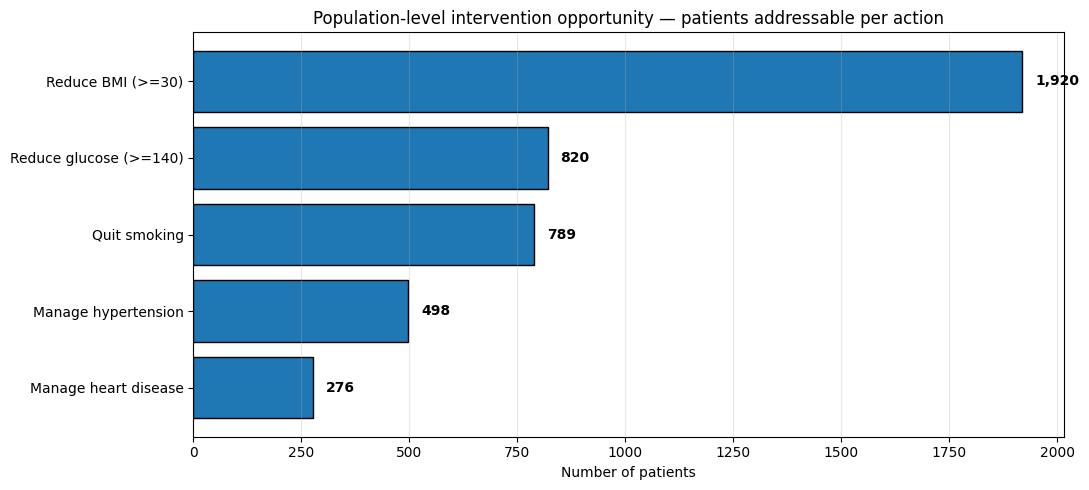

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict

# ============================================================
# 1. REBUILD THE CALIBRATED MODEL (we need it for counterfactuals)
# ============================================================
df_prep = df.copy()
df_prep['bmi'] = pd.to_numeric(df_prep['bmi'], errors='coerce')
df_prep['bmi'] = df_prep['bmi'].fillna(df_prep['bmi'].median())
df_prep = df_prep[df_prep['gender'] != 'Other'].reset_index(drop=True)

df_clean = df_prep.drop(columns=['id']).copy()
df_clean['gender'] = df_clean['gender'].map({'Male': 0, 'Female': 1})
df_clean['ever_married'] = df_clean['ever_married'].map({'No': 0, 'Yes': 1})
df_clean['Residence_type'] = df_clean['Residence_type'].map({'Rural': 0, 'Urban': 1})
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True)

X_all = df_clean.drop(columns=['stroke'])
y_all = df_clean['stroke']

scaler = StandardScaler()
X_all_s_arr = scaler.fit_transform(X_all)
X_all_s = pd.DataFrame(X_all_s_arr, columns=X_all.columns)

# Fit calibrated model on ALL data — we need it for counterfactual scoring
base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
calibrated_model = CalibratedClassifierCV(base, method='sigmoid', cv=5)
calibrated_model.fit(X_all_s, y_all)

# Helper to score a modified feature vector
def score_patient(features_df):
    """Take a raw feature DataFrame, scale, and return calibrated risk %."""
    scaled = scaler.transform(features_df)
    return calibrated_model.predict_proba(scaled)[:, 1] * 100

# ============================================================
# 2. RISK FACTOR IDENTIFICATION + COUNTERFACTUAL LOGIC
# ============================================================
def analyse_patient(row_idx):
    """
    For a given patient, identify risk factors and calculate
    how much their risk would drop if each modifiable one was fixed.
    """
    patient_raw = df_prep.iloc[row_idx]
    patient_features = X_all.iloc[[row_idx]].copy()  # keeps as DataFrame
    baseline_risk = score_patient(patient_features)[0]

    risk_factors = []      # list of (factor_name, current_value_text)
    interventions = []     # list of (action_text, new_risk, delta)

    # --- Age (fixed, but flag it) ---
    age = patient_raw['age']
    if age >= 65:
        risk_factors.append(f"Advanced age ({age:.0f} years)")
    elif age >= 55:
        risk_factors.append(f"Older age ({age:.0f} years)")

    # --- Hypertension (modifiable via medication/lifestyle) ---
    if patient_raw['hypertension'] == 1:
        risk_factors.append("Diagnosed hypertension")
        cf = patient_features.copy()
        cf['hypertension'] = 0
        new_risk = score_patient(cf)[0]
        interventions.append((
            "Control blood pressure (medication + lifestyle)",
            new_risk, baseline_risk - new_risk
        ))

    # --- Heart disease (largely fixed once diagnosed, but manageable) ---
    if patient_raw['heart_disease'] == 1:
        risk_factors.append("History of heart disease")
        cf = patient_features.copy()
        cf['heart_disease'] = 0
        new_risk = score_patient(cf)[0]
        interventions.append((
            "Aggressive cardiac management (cardiologist referral)",
            new_risk, baseline_risk - new_risk
        ))

    # --- Glucose (modifiable via diet/exercise/medication) ---
    glucose = patient_raw['avg_glucose_level']
    if glucose >= 200:
        risk_factors.append(f"Very high glucose ({glucose:.0f} mg/dL — diabetic range)")
        cf = patient_features.copy()
        # Counterfactual: bring glucose down to normal (~100)
        cf['avg_glucose_level'] = (100 - X_all['avg_glucose_level'].mean()) / X_all['avg_glucose_level'].std() * scaler.scale_[list(X_all.columns).index('avg_glucose_level')] + scaler.mean_[list(X_all.columns).index('avg_glucose_level')]
        # Simpler: just set to 100 in raw, re-scale via score_patient
        cf_raw = X_all.iloc[[row_idx]].copy()
        cf_raw['avg_glucose_level'] = 100
        new_risk = score_patient(cf_raw)[0]
        interventions.append((
            "Reduce glucose to normal range (~100 mg/dL) via diet + medication",
            new_risk, baseline_risk - new_risk
        ))
    elif glucose >= 140:
        risk_factors.append(f"Elevated glucose ({glucose:.0f} mg/dL — pre-diabetic)")
        cf_raw = X_all.iloc[[row_idx]].copy()
        cf_raw['avg_glucose_level'] = 100
        new_risk = score_patient(cf_raw)[0]
        interventions.append((
            "Reduce glucose to normal range (~100 mg/dL) via lifestyle changes",
            new_risk, baseline_risk - new_risk
        ))

    # --- BMI (modifiable) ---
    bmi = patient_raw['bmi']
    if bmi >= 35:
        risk_factors.append(f"Severe obesity (BMI {bmi:.1f})")
        cf_raw = X_all.iloc[[row_idx]].copy()
        cf_raw['bmi'] = 25  # normal BMI target
        new_risk = score_patient(cf_raw)[0]
        interventions.append((
            "Reduce BMI to healthy range (~25) via structured weight loss programme",
            new_risk, baseline_risk - new_risk
        ))
    elif bmi >= 30:
        risk_factors.append(f"Obese (BMI {bmi:.1f})")
        cf_raw = X_all.iloc[[row_idx]].copy()
        cf_raw['bmi'] = 25
        new_risk = score_patient(cf_raw)[0]
        interventions.append((
            "Reduce BMI to healthy range (~25) via diet + exercise",
            new_risk, baseline_risk - new_risk
        ))

    # --- Smoking status ---
    smoking = patient_raw['smoking_status']
    if smoking == 'smokes':
        risk_factors.append("Current smoker")
        cf_raw = X_all.iloc[[row_idx]].copy()
        # Zero out all smoking dummies, effectively "never smoked" baseline
        for col in cf_raw.columns:
            if col.startswith('smoking_status_'):
                cf_raw[col] = 0
        new_risk = score_patient(cf_raw)[0]
        interventions.append((
            "Quit smoking (biggest single lifestyle change available)",
            new_risk, baseline_risk - new_risk
        ))
    elif smoking == 'formerly smoked':
        risk_factors.append("Former smoker (residual risk)")
        # No intervention — can't un-smoke history

    # ============================================================
    # BUILD THE PRESCRIPTIVE TEXT
    # ============================================================
    if len(risk_factors) == 0:
        summary_text = (f"Low overall risk ({baseline_risk:.1f}%). "
                        "No major modifiable risk factors identified. "
                        "Maintain healthy lifestyle.")
    else:
        parts = [f"Risk profile ({baseline_risk:.1f}%): " + "; ".join(risk_factors) + "."]

        if interventions:
            parts.append(" Recommended actions:")
            # Sort interventions by biggest risk reduction
            interventions.sort(key=lambda x: x[2], reverse=True)
            for action, new_risk, delta in interventions:
                pct_reduction = (delta / baseline_risk) * 100 if baseline_risk > 0 else 0
                parts.append(
                    f" • {action} → risk drops from {baseline_risk:.1f}% "
                    f"to {new_risk:.1f}% (−{delta:.1f} pp, a {pct_reduction:.0f}% relative reduction)."
                )

            # Combined intervention — everything at once
            cf_all = X_all.iloc[[row_idx]].copy()
            if patient_raw['hypertension'] == 1:
                cf_all['hypertension'] = 0
            if patient_raw['heart_disease'] == 1:
                cf_all['heart_disease'] = 0
            if glucose >= 140:
                cf_all['avg_glucose_level'] = 100
            if bmi >= 30:
                cf_all['bmi'] = 25
            if smoking == 'smokes':
                for col in cf_all.columns:
                    if col.startswith('smoking_status_'):
                        cf_all[col] = 0
            combined_risk = score_patient(cf_all)[0]
            combined_delta = baseline_risk - combined_risk
            combined_pct = (combined_delta / baseline_risk) * 100 if baseline_risk > 0 else 0
            parts.append(
                f" ★ If ALL modifiable factors addressed: "
                f"risk drops to {combined_risk:.1f}% "
                f"(−{combined_delta:.1f} pp, a {combined_pct:.0f}% relative reduction)."
            )
        else:
            parts.append(" Risk factors are largely non-modifiable (age-driven). "
                         "Focus on regular monitoring and preventive care.")

        summary_text = "".join(parts)

    return summary_text

# ============================================================
# 3. APPLY TO EVERY PATIENT
# ============================================================
print("Generating prescriptive text for every patient... "
      f"(this takes ~30-60 seconds for {len(df_prep):,} rows)")

df_final['prescriptive_advice'] = [analyse_patient(i) for i in range(len(df_prep))]

print("Done.\n")

# ============================================================
# 4. SHOW EXAMPLES ACROSS RISK BANDS
# ============================================================
for band in ['Green (Low)', 'Yellow (Moderate)', 'Orange (High)', 'Red (Very High)']:
    sample = df_final[df_final['risk_band'] == band].sample(1, random_state=7).iloc[0]
    print(f"\n{'='*80}")
    print(f"BAND: {band}  |  ID: {sample['id']}  |  Predicted risk: {sample['stroke_risk_%']:.2f}%")
    print(f"Age: {sample['age']:.0f} | Glucose: {sample['avg_glucose_level']:.0f} | "
          f"BMI: {sample['bmi']:.1f} | HT: {sample['hypertension']} | "
          f"HD: {sample['heart_disease']} | Smoking: {sample['smoking_status']}")
    print(f"{'='*80}")
    print(sample['prescriptive_advice'])

# ============================================================
# 5. EXPORT — CSV + STYLED EXCEL
# ============================================================
export_df = df_final.copy()
if 'decile' in export_df.columns:
    export_df = export_df.drop(columns=['decile'])

column_order = ['id', 'gender', 'age', 'hypertension', 'heart_disease',
                'ever_married', 'work_type', 'Residence_type',
                'avg_glucose_level', 'bmi', 'smoking_status',
                'stroke', 'stroke_risk_%', 'risk_band', 'prescriptive_advice']
column_order = [c for c in column_order if c in export_df.columns]
export_df = export_df[column_order]

export_df.to_csv('stroke_data_with_prescriptive_advice.csv', index=False)
print("\n✓ Saved CSV: stroke_data_with_prescriptive_advice.csv")

# Excel with colour bands + wrapped advice column
with pd.ExcelWriter('stroke_data_with_prescriptive_advice.xlsx',
                     engine='xlsxwriter') as writer:
    export_df.to_excel(writer, sheet_name='Scored Data', index=False)
    workbook = writer.book
    worksheet = writer.sheets['Scored Data']
    worksheet.freeze_panes(1, 0)

    wrap_fmt = workbook.add_format({'text_wrap': True, 'valign': 'top'})
    worksheet.set_column('A:L', 12)
    worksheet.set_column('M:M', 14)   # stroke_risk_%
    worksheet.set_column('N:N', 20)   # risk_band
    worksheet.set_column('O:O', 90, wrap_fmt)  # prescriptive_advice

    green_fmt  = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100'})
    yellow_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C6500'})
    orange_fmt = workbook.add_format({'bg_color': '#FFD8B1', 'font_color': '#974706'})
    red_fmt    = workbook.add_format({'bg_color': '#FFC7CE', 'font_color': '#9C0006'})
    n_rows = len(export_df)
    for keyword, fmt in [('Green', green_fmt), ('Yellow', yellow_fmt),
                          ('Orange', orange_fmt), ('Red', red_fmt)]:
        worksheet.conditional_format(f'N2:N{n_rows+1}', {
            'type': 'text', 'criteria': 'containing',
            'value': keyword, 'format': fmt})

    worksheet.conditional_format(f'M2:M{n_rows+1}', {
        'type': '3_color_scale',
        'min_color': '#63BE7B', 'mid_color': '#FFEB84', 'max_color': '#F8696B'})

print("✓ Saved Excel: stroke_data_with_prescriptive_advice.xlsx")

# ============================================================
# 6. VISUAL: TOTAL POPULATION-LEVEL IMPACT OF INTERVENTIONS
# ============================================================
# Aggregate: how many patients could benefit from each intervention?
interventions_map = {
    'Manage hypertension': (df_prep['hypertension'] == 1).sum(),
    'Manage heart disease': (df_prep['heart_disease'] == 1).sum(),
    'Reduce glucose (>=140)': (df_prep['avg_glucose_level'] >= 140).sum(),
    'Reduce BMI (>=30)': (df_prep['bmi'] >= 30).sum(),
    'Quit smoking': (df_prep['smoking_status'] == 'smokes').sum(),
}
impact_df = pd.DataFrame({
    'Intervention': list(interventions_map.keys()),
    'Patients affected': list(interventions_map.values())
}).sort_values('Patients affected', ascending=True)

plt.figure(figsize=(11, 5))
bars = plt.barh(impact_df['Intervention'], impact_df['Patients affected'],
                color='#1f77b4', edgecolor='black')
for bar, val in zip(bars, impact_df['Patients affected']):
    plt.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontweight='bold')
plt.title('Population-level intervention opportunity — patients addressable per action')
plt.xlabel('Number of patients')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()